# Validate an exp_00 incoming run

A first-pass quality-control notebook for the portable rig output. It follows the future `neuro_analysis_suite` producer contract: trial-level data, event markers, sample-level gaze data, and a deliberately explicit missing-neural-data check.

Run this from the repository's `data_analysis` Nix shell: `nix develop`. The notebook reads raw files and writes only derived CSV/JSON files under `<run>/derived/`.

In [1]:
from __future__ import annotations

import json
import os
import re
import shutil
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

DATA_ROOT = Path(os.environ.get('CCLAB_DATA', Path.home() / 'dev/research/data'))
RUN_ID = os.environ.get('CCLAB_RUN_ID', '2026-10-05_165406_exp')
run_dir = DATA_ROOT / RUN_ID
assert run_dir.is_dir(), f'Run directory not found: {run_dir}'
derived_dir = run_dir / 'derived'
derived_dir.mkdir(exist_ok=True)
print(f'Validating: {run_dir}')

Validating: /Users/q/dev/research/data/2026-10-05_165406_exp


In [2]:
mat_path = next(run_dir.glob('experiment/**/*.mat'), None)
edf_path = next(run_dir.glob('experiment/**/*.edf'), None)
transcript_path = run_dir / 'logs' / 'runner_transcript.txt'
metadata_path = run_dir / 'run_metadata.json'

files = pd.DataFrame({
    'artifact': ['MAT trial table', 'EyeLink EDF', 'runner transcript', 'run metadata'],
    'path': [mat_path, edf_path, transcript_path, metadata_path],
})
files['present'] = files['path'].map(lambda path: path is not None and Path(path).is_file())
display(files)
assert files['present'].all(), 'This run is missing one or more required behavioral artifacts.'
run_metadata = json.loads(metadata_path.read_text())
run_metadata

,artifact,path,present
0,MAT trial table,/Users/q/dev/research/data/2026-10-05_165406_e...,True
1,EyeLink EDF,/Users/q/dev/research/data/2026-10-05_165406_e...,True
2,runner transcript,/Users/q/dev/research/data/2026-10-05_165406_e...,True
3,run metadata,/Users/q/dev/research/data/2026-10-05_165406_e...,True


{'session_id': '2026-10-05_165406_exp',
 'started_local': '2026-10-05T16:54:06.9100756-07:00',
 'computer_name': 'CNS-DD1XSH0R3',
 'computer_profile': 'lab_120',
 'bench_dummy': False,
 'video_source': 'local',
 'screen': 2,
 'movie_project': 'C:\\Users\\cclab\\Desktop\\CCLabRig\\cclab_movie_project',
 'benchmark_project': None,
 'rig_config': 'C:\\Users\\cclab\\Desktop\\CCLabRig\\cclab_movie_project\\Code\\cclab-matlab-tools\\cfg\\rig-right.txt'}

## Export the MATLAB table

MATLAB tables are opaque to SciPy. MATLAB is therefore the narrow import boundary: it exports `Results` to an open CSV once, and all later cells use that CSV. Set `CCLAB_MATLAB` if `matlab` is not on `PATH`.

In [3]:
results_csv = derived_dir / 'trials_from_mat.csv'

def matlab_binary() -> str:
    candidates = [
        os.environ.get('CCLAB_MATLAB'),
        shutil.which('matlab'),
        '/Applications/MATLAB_R2025a.app/bin/matlab',
    ]
    return next((candidate for candidate in candidates if candidate and Path(candidate).exists()), '')

def matlab_string(path: Path) -> str:
    return str(path).replace("'", "''")

if not results_csv.exists():
    matlab = matlab_binary()
    assert matlab, 'MATLAB is required once to export the Results table; set CCLAB_MATLAB.'
    command = (
        f"data = load('{matlab_string(mat_path)}'); "
        f"writetable(data.Results, '{matlab_string(results_csv)}');"
    )
    subprocess.run([matlab, '-batch', command], check=True)

trials = pd.read_csv(results_csv)
required_trial_columns = {
    'TrialNum', 'VideoA', 'CategoryA', 'VideoB', 'CategoryB', 'SameCategory',
    'FixAcquired_ms', 'InterleaveOff_ms', 'RewardOn_ms', 'AbortPhase',
    'TrialSuccess', 'RewardSize',
}
missing_columns = required_trial_columns - set(trials.columns)
assert not missing_columns, f'Missing trial columns: {sorted(missing_columns)}'
display(trials)

,TrialNum,VideoA,CategoryA,VideoB,CategoryB,SameCategory,SegDur_s,TimesShownBeforeA,TimesShownBeforeB,FixAcquired_ms,InterleaveOff_ms,RewardOn_ms,AbortPhase,TrialSuccess,RewardSize
0,1,00189DVD.mp4,nature,foraging03DVD.mp4,social_undir,0,2,0,0,850.9669,14070.6535,14999.6185,NaN,1,600
1,2,foraging03DVD.mp4,social_undir,foraging04DVD.mp4,social_undir,1,2,1,0,850.4786,13973.3607,NaN,Select_and_play,0,0
2,3,foraging04DVD.mp4,social_undir,foraging03DVD.mp4,social_undir,1,2,0,1,850.6338,14568.8500,15419.1070,NaN,1,600
3,4,00191DVD.mp4,nature,foraging02DVD.mp4,social_undir,0,2,0,0,850.9646,14467.9134,15300.7165,NaN,1,600
4,5,foraging04DVD.mp4,social_undir,00191DVD.mp4,nature,0,2,1,1,850.8698,14476.5334,15306.7208,NaN,1,600
5,6,00182DVD.mp4,nature,00189DVD.mp4,nature,1,2,0,1,850.8024,1787.4820,NaN,Select_and_play,0,0
6,7,foraging06DVD.mp4,social_undir,00181DVD.mp4,nature,0,2,0,0,851.0219,14217.2452,15123.7823,NaN,1,600
7,8,foraging02DVD.mp4,social_undir,00191DVD.mp4,nature,0,2,1,2,850.6115,2385.4524,NaN,Select_and_play,0,0
8,9,foraging02DVD.mp4,social_undir,foraging03DVD.mp4,social_undir,1,2,1,2,851.1349,11903.9679,NaN,Select_and_play,0,0


,value
trials_started,9.00000
trials_completed,5.00000
trials_aborted,4.00000
mean_fixation_acquisition_ms,850.83160
mean_completed_interleave_ms,14360.23910
mean_completed_reward_on_ms,15229.98902


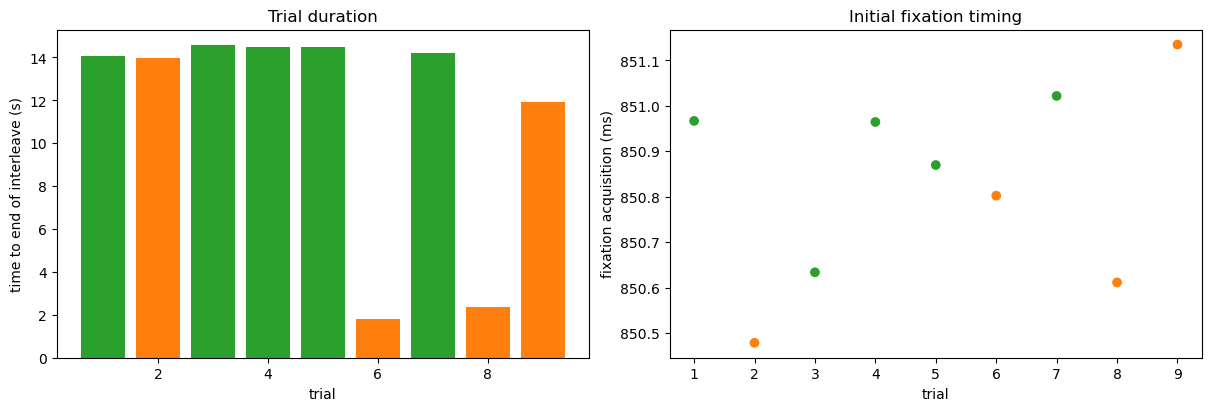

In [4]:
summary = pd.Series({
    'trials_started': len(trials),
    'trials_completed': int(trials['TrialSuccess'].sum()),
    'trials_aborted': int((trials['TrialSuccess'] == 0).sum()),
    'mean_fixation_acquisition_ms': trials['FixAcquired_ms'].mean(),
    'mean_completed_interleave_ms': trials.loc[trials['TrialSuccess'] == 1, 'InterleaveOff_ms'].mean(),
    'mean_completed_reward_on_ms': trials.loc[trials['TrialSuccess'] == 1, 'RewardOn_ms'].mean(),
})
display(summary.to_frame('value'))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
colors = np.where(trials['TrialSuccess'].astype(bool), 'tab:green', 'tab:orange')
axes[0].bar(trials['TrialNum'], trials['InterleaveOff_ms'] / 1000, color=colors)
axes[0].set(xlabel='trial', ylabel='time to end of interleave (s)', title='Trial duration')
axes[1].scatter(trials['TrialNum'], trials['FixAcquired_ms'], c=colors)
axes[1].set(xlabel='trial', ylabel='fixation acquisition (ms)', title='Initial fixation timing')
plt.show()

## Decode EyeLink events and samples

The EDF is converted locally with `edf2asc` if necessary. `SegOn` and `SegOff` are the behavioral event spine. They should later be joined to neural `pulse` / `t_pulse` values rather than treated as neural data themselves.

In [5]:
asc_path = edf_path.with_suffix('.asc')
if not asc_path.exists():
    edf2asc = shutil.which('edf2asc')
    assert edf2asc, 'Install the EyeLink EDF tools so edf2asc is on PATH.'
    subprocess.run([edf2asc, edf_path.name], cwd=edf_path.parent, check=True)
assert asc_path.exists(), f'edf2asc did not create {asc_path}'

message_pattern = re.compile(r'^MSG\s+(?P<t_eye_ms>\d+)\s+(?P<label>.+)$')
segment_pattern = re.compile(r'^Seg(?P<edge>On|Off)_(?P<trial>\d+)_(?P<segment>\d+)_(?P<movie>[AB])$')
messages = []
for line in asc_path.read_text(errors='replace').splitlines():
    match = message_pattern.match(line)
    if not match:
        continue
    event = match.groupdict()
    segment = segment_pattern.match(event['label'])
    if segment:
        event.update(segment.groupdict())
        event['event'] = f"segment_{event['edge'].lower()}"
    elif event['label'].startswith('TrialStart_'):
        event['event'] = 'trial_start'
        event['trial'] = event['label'].split('_')[-1]
    elif event['label'].startswith('Reward_'):
        event['event'] = 'reward'
        event['trial'] = event['label'].split('_')[-1]
    else:
        continue
    messages.append(event)

events = pd.DataFrame(messages)
events['t_eye_ms'] = pd.to_numeric(events['t_eye_ms'])
for column in ['trial', 'segment']:
    if column in events:
        events[column] = pd.to_numeric(events[column], errors='coerce').astype('Int64')
events.to_csv(derived_dir / 'events_from_edf.csv', index=False)
display(events.groupby('event').size().rename('count').to_frame())
display(events.head(12))

,count
event,
reward,5
segment_off,43
segment_on,43
trial_start,10


,t_eye_ms,label,event,trial,edge,segment,movie
0,2332018,TrialStart_1,trial_start,1,NaN,<NA>,NaN
1,2333128,SegOn_1_1_A,segment_on,1,On,1,A
2,2335129,SegOff_1_1_A,segment_off,1,Off,1,A
3,2335162,SegOn_1_1_B,segment_on,1,On,1,B
4,2337162,SegOff_1_1_B,segment_off,1,Off,1,B
5,2337312,SegOn_1_2_A,segment_on,1,On,2,A
6,2339321,SegOff_1_2_A,segment_off,1,Off,2,A
7,2339487,SegOn_1_2_B,segment_on,1,On,2,B
8,2341487,SegOff_1_2_B,segment_off,1,Off,2,B
9,2341770,SegOn_1_3_A,segment_on,1,On,3,A


In [6]:
sample_pattern = re.compile(r'^(?P<t_eye_ms>\d+)\s+(?P<x>-?\d+(?:\.\d+)?)\s+(?P<y>-?\d+(?:\.\d+)?)\s+(?P<pupil>-?\d+(?:\.\d+)?)')
samples = []
for line in asc_path.read_text(errors='replace').splitlines():
    match = sample_pattern.match(line)
    if match:
        samples.append({key: float(value) for key, value in match.groupdict().items()})
samples = pd.DataFrame(samples)
samples['t_eye_ms'] = samples['t_eye_ms'].astype('int64')
dt_ms = samples['t_eye_ms'].diff()
gaps = samples.loc[dt_ms > 2, ['t_eye_ms']].copy()
gaps['gap_ms'] = dt_ms[dt_ms > 2].astype('int64')
qc = {
    'n_samples': int(len(samples)),
    'duration_s': float((samples['t_eye_ms'].iloc[-1] - samples['t_eye_ms'].iloc[0]) / 1000),
    'n_gaps_over_2ms': int(len(gaps)),
    'max_gap_ms': int(dt_ms.max()),
    'missing_x_or_y': int(samples[['x', 'y']].isna().any(axis=1).sum()),
}
(derived_dir / 'eyelink_qc.json').write_text(json.dumps(qc, indent=2) + '\n')
display(pd.Series(qc).to_frame('value'))
display(gaps)

,value
n_samples,130942.000
duration_s,131.031
n_gaps_over_2ms,10.000
max_gap_ms,11.000
missing_x_or_y,0.000


,t_eye_ms,gap_ms
105,2331964,11
18218,2350086,10
34274,2366151,10
52784,2384669,9
71162,2403057,11
89565,2421470,11
93425,2425339,10
111626,2443548,9
116085,2448015,9
130069,2462008,10


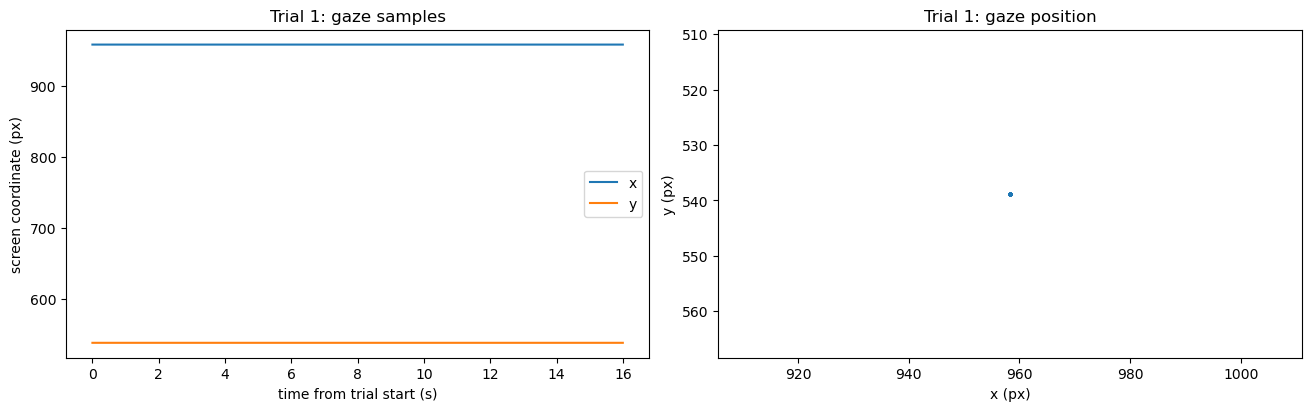

In [7]:
first_trial = int(events.loc[events['event'] == 'trial_start', 'trial'].iloc[0])
first_trial_t0 = events.loc[(events['event'] == 'trial_start') & (events['trial'] == first_trial), 't_eye_ms'].iloc[0]
window = samples[(samples['t_eye_ms'] >= first_trial_t0) & (samples['t_eye_ms'] <= first_trial_t0 + 16_000)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
axes[0].plot((window['t_eye_ms'] - first_trial_t0) / 1000, window['x'], label='x')
axes[0].plot((window['t_eye_ms'] - first_trial_t0) / 1000, window['y'], label='y')
axes[0].set(xlabel='time from trial start (s)', ylabel='screen coordinate (px)', title=f'Trial {first_trial}: gaze samples')
axes[0].legend()
axes[1].scatter(window['x'], window['y'], s=2, alpha=0.25)
axes[1].invert_yaxis()
axes[1].set(xlabel='x (px)', ylabel='y (px)', title=f'Trial {first_trial}: gaze position')
plt.show()

## Neural-data handoff

This run has no neural-acquisition export. Do not infer neural signal quality from the EDF or the presence of TTL messages. When the acquisition system export arrives, place it in `<run>/neural/` and provide a table containing at least `pulse` and `t_pulse` in the neural clock. The `events_from_edf.csv` file written above is the behavioral side of that alignment contract.

In [8]:
neural_dir = run_dir / 'neural'
neural_files = list(neural_dir.rglob('*')) if neural_dir.is_dir() else []
print(f'Neural files found: {len([path for path in neural_files if path.is_file()])}')
if not neural_files:
    print('Expected next: export the acquisition-system data and its digital TTL event timestamps.')

print(f'Derived validation artifacts: {derived_dir}')

Neural files found: 0
Expected next: export the acquisition-system data and its digital TTL event timestamps.
Derived validation artifacts: /Users/q/dev/research/data/2026-10-05_165406_exp/derived
